# Comparisons with BGEP ULS sea ice draft estimates updated with new data

**Summary:** In this notebook, we produce comparisons of the gridded ICESat-2 sea ice thickness data with draft measurements obtained from Upward Looking Sonar moorings deployed in the Beaufort Sea. 

 
**Version history**: Version 1 (01/01/2022)
 

# Import notebook dependencies

In [2]:
import xarray as xr 
import pandas as pd
import numpy as np
import itertools
import pyproj 
from netCDF4 import Dataset
import scipy.interpolate 
from utils.read_data_utils import read_book_data, read_IS2SITMOGR4 # Helper function for reading the data from the bucket
from utils.plotting_utils import compute_gridcell_winter_means, interactiveArcticMaps, interactive_winter_mean_maps, interactive_winter_comparison_lineplot # Plotting
from scipy import stats
import datetime
# Plotting dependencies
import cartopy.crs as ccrs
from textwrap import wrap
import hvplot.pandas
import holoviews as hv
import matplotlib.pyplot as plt
from matplotlib.axes import Axes
from cartopy.mpl.geoaxes import GeoAxes
GeoAxes._pcolormesh_patched = Axes.pcolormesh # Helps avoid some weird issues with the polar projection 
%config InlineBackend.figure_format = 'retina'
import matplotlib as mpl

mpl.rcParams['figure.dpi'] = 200 # Sets figure size in the notebook

# Remove warnings to improve display
import warnings 
warnings.filterwarnings('ignore') 


In [3]:
# DO ONE RUN APR 2021 WITH SM AS THIS IS WHEN IT IS AVAILABLE TO
  

start_date = "Nov 2018"
end_date = "July 2021"
options = {
    'IS-2/SM': {'thickness': 'ice_thickness_sm', 'snow_depth': 'snow_depth_sm'},
    'CS-2/SM': {'thickness': 'cs2_sea_ice_thickness_UBRIS', 'snow_depth': 'snow_depth_sm'}
}




In [4]:
IS2SITMOGR4_v3 = read_IS2SITMOGR4(data_type='zarr-s3', persist=True) 

IS2SITMOGR4_v3

load zarr from S3 bucket
zarr_path: s3://icesat-2-sea-ice-us-west-2/IS2SITMOGR4_V3/IS2SITMOGR4_V3_201811-202404.zarr
<xarray.Dataset>
Dimensions:                         (time: 46, y: 448, x: 304)
Coordinates:
    latitude                        (y, x) float32 dask.array<chunksize=(224, 304), meta=np.ndarray>
    longitude                       (y, x) float32 dask.array<chunksize=(224, 304), meta=np.ndarray>
  * time                            (time) datetime64[ns] 2018-11-01 ... 2024...
  * x                               (x) float32 -3.838e+06 ... 3.738e+06
  * y                               (y) float32 5.838e+06 ... -5.338e+06
Data variables: (12/27)
    crs                             (time) int32 dask.array<chunksize=(46,), meta=np.ndarray>
    freeboard                       (time, y, x) float32 dask.array<chunksize=(1, 448, 304), meta=np.ndarray>
    freeboard_int                   (time, y, x) float32 dask.array<chunksize=(1, 448, 304), meta=np.ndarray>
    ice_density        

<xarray.Dataset>
Dimensions:                         (time: 46, y: 448, x: 304)
Coordinates:
    latitude                        (y, x) float32 31.1 31.2 ... 34.58 34.47
    longitude                       (y, x) float32 168.3 168.1 ... -10.18 -9.999
  * time                            (time) datetime64[ns] 2018-11-01 ... 2024...
  * x                               (x) float32 -3.838e+06 ... 3.738e+06
  * y                               (y) float32 5.838e+06 ... -5.338e+06
Data variables: (12/27)
    crs                             (time) int32 dask.array<chunksize=(46,), meta=np.ndarray>
    freeboard                       (time, y, x) float32 dask.array<chunksize=(1, 448, 304), meta=np.ndarray>
    freeboard_int                   (time, y, x) float32 dask.array<chunksize=(1, 448, 304), meta=np.ndarray>
    ice_density                     (time, y, x) float32 dask.array<chunksize=(1, 448, 304), meta=np.ndarray>
    ice_density_j22                 (time, y, x) float32 dask.array<chunksize=(1, 448, 304), meta=np.ndarray>
    ice_thickness                   (time, y, x) float32 dask.array<chunksize=(1, 448, 304), meta=np.ndarray>
    ...                              ...
    snow_density_sm                 (time, y, x) float32 dask.array<chunksize=(1, 448, 304), meta=np.ndarray>
    snow_density_w99                (time, y, x) float32 dask.array<chunksize=(1, 448, 304), meta=np.ndarray>
    snow_depth                      (time, y, x) float32 dask.array<chunksize=(1, 448, 304), meta=np.ndarray>
    snow_depth_int                  (time, y, x) float32 dask.array<chunksize=(1, 448, 304), meta=np.ndarray>
    snow_depth_mw99                 (time, y, x) float32 dask.array<chunksize=(1, 448, 304), meta=np.ndarray>
    snow_depth_sm                   (time, y, x) float32 dask.array<chunksize=(1, 448, 304), meta=np.ndarray>
Attributes:
    contact:      Alek Petty (akpetty@umd.edu)
    description:  Aggregated IS2SITMOGR4 V3 dataset.
    history:      Created 28/11/23
    reference:    Official NSIDC data doi: 10.5067/CV6JEXEE31HF. Derived data...

In [5]:

# Get some map proj info needed for later functions
out_proj = 'EPSG:3411'
mapProj = pyproj.Proj("+init=" + out_proj)

xIS2 = IS2SITMOGR4_v3.x.values
yIS2 = IS2SITMOGR4_v3.y.values
xptsIS2, yptsIS2 = np.meshgrid(xIS2, yIS2)

out_lons = IS2SITMOGR4_v3.longitude.values
out_lats = IS2SITMOGR4_v3.latitude.values

# Set Inner Arctic domain
innerArctic = [1,2,3,4,5,6]



In [6]:
import glob
from datetime import datetime
def add_time_dim_v3(xda):
    """ dummy function to just set current time as a new dimension to concat files over, change later! """
    xda = xda.set_coords(["latitude","longitude", "y", "x"])
    xda = xda.expand_dims(time = [datetime.now()])
    return xda

def read_IS2SITMOGR4_SUMMER(version='V0', local_data_path="./data/IS2SITMOGR4_SUMMER/"): 
    """ Read in IS2SITMOGR4 summer monthly gridded thickness dataset from local netcdf files

    """
    
    print(local_data_path+version+'/*.nc')
    filenames = glob.glob(local_data_path+version+'/*.nc')
    if len(filenames) == 0: 
        raise ValueError("No files, exit")
        return None
    
    dates = [pd.to_datetime(file.split("IS2SIT_SUMMER_01_")[1].split("_")[0], format = "%Y%m")  for file in filenames]
    # Add a dummy time then add the dates I want, seemed the easiest solution
    is2_ds = xr.open_mfdataset(filenames, preprocess = add_time_dim_v3, engine='netcdf4')
            
    is2_ds["time"] = dates

    # Sort by time as glob file list wasn't!
    is2_ds = is2_ds.sortby("time")
    is2_ds = is2_ds.set_coords(["latitude","longitude","y","x"])
    
    is2_ds = is2_ds.assign_coords(longitude=(["y","x"], is2_ds.longitude.values))
    is2_ds = is2_ds.assign_coords(latitude=(["y","x"], is2_ds.latitude.values))
    
    is2_ds = is2_ds.assign_attrs(description="Aggregated IS2SITMOGR4 summer "+version+" dataset.")

    return is2_ds
IS2SITMOGR4_summer_v0 = read_IS2SITMOGR4_SUMMER()
IS2SITMOGR4_summer_v0


./data/IS2SITMOGR4_SUMMER/V0/*.nc


<xarray.Dataset>
Dimensions:                         (time: 11, y: 448, x: 304)
Coordinates:
  * time                            (time) datetime64[ns] 2019-05-01 ... 2021...
    longitude                       (y, x) float32 168.3 168.1 ... -10.18 -9.999
    latitude                        (y, x) float32 31.1 31.2 ... 34.58 34.47
  * x                               (x) float32 -3.838e+06 ... 3.738e+06
  * y                               (y) float32 5.838e+06 ... -5.338e+06
Data variables: (12/26)
    crs                             (time) int32 -2147483647 ... -2147483647
    ice_thickness_sm                (time, y, x) float32 dask.array<chunksize=(1, 448, 304), meta=np.ndarray>
    ice_thickness_unc               (time, y, x) float32 dask.array<chunksize=(1, 448, 304), meta=np.ndarray>
    num_segments                    (time, y, x) float32 dask.array<chunksize=(1, 448, 304), meta=np.ndarray>
    mean_day_of_month               (time, y, x) float32 dask.array<chunksize=(1, 448, 304), meta=np.ndarray>
    snow_depth_sm                   (time, y, x) float32 dask.array<chunksize=(1, 448, 304), meta=np.ndarray>
    ...                              ...
    ice_thickness_unc_freeboard     (time, y, x) float32 dask.array<chunksize=(1, 448, 304), meta=np.ndarray>
    ice_thickness_unc_ice_density   (time, y, x) float32 dask.array<chunksize=(1, 448, 304), meta=np.ndarray>
    ice_thickness_unc_snow_density  (time, y, x) float32 dask.array<chunksize=(1, 448, 304), meta=np.ndarray>
    ice_thickness_unc_snow_depth    (time, y, x) float32 dask.array<chunksize=(1, 448, 304), meta=np.ndarray>
    sea_ice_conc                    (time, y, x) float32 dask.array<chunksize=(1, 448, 304), meta=np.ndarray>
    region_mask                     (time, y, x) float32 dask.array<chunksize=(1, 448, 304), meta=np.ndarray>
Attributes:
    contact:      Alek Petty (akpetty@umd.edu)
    description:  Aggregated IS2SITMOGR4 summer V0 dataset.
    history:      Created 20/12/23

In [7]:
IS2SITMOGR4_v3 = IS2SITMOGR4_summer_v0.merge(IS2SITMOGR4_v3)
IS2SITMOGR4_v3

<xarray.Dataset>
Dimensions:                         (time: 57, x: 304, y: 448)
Coordinates:
  * time                            (time) datetime64[ns] 2018-11-01 ... 2024...
  * x                               (x) float32 -3.838e+06 ... 3.738e+06
  * y                               (y) float32 5.838e+06 ... -5.338e+06
    longitude                       (y, x) float32 168.3 168.1 ... -10.18 -9.999
    latitude                        (y, x) float32 31.1 31.2 ... 34.58 34.47
Data variables: (12/36)
    crs                             (time) float64 dask.array<chunksize=(57,), meta=np.ndarray>
    ice_thickness_sm                (time, y, x) float32 dask.array<chunksize=(1, 448, 304), meta=np.ndarray>
    ice_thickness_unc               (time, y, x) float32 dask.array<chunksize=(1, 448, 304), meta=np.ndarray>
    num_segments                    (time, y, x) float32 dask.array<chunksize=(1, 448, 304), meta=np.ndarray>
    mean_day_of_month               (time, y, x) float32 dask.array<chunksize=(1, 448, 304), meta=np.ndarray>
    snow_depth_sm                   (time, y, x) float32 dask.array<chunksize=(1, 448, 304), meta=np.ndarray>
    ...                              ...
    ice_type                        (time, y, x) float32 dask.array<chunksize=(1, 448, 304), meta=np.ndarray>
    snow_density                    (time, y, x) float32 dask.array<chunksize=(1, 448, 304), meta=np.ndarray>
    snow_density_w99                (time, y, x) float32 dask.array<chunksize=(1, 448, 304), meta=np.ndarray>
    snow_depth                      (time, y, x) float32 dask.array<chunksize=(1, 448, 304), meta=np.ndarray>
    snow_depth_int                  (time, y, x) float32 dask.array<chunksize=(1, 448, 304), meta=np.ndarray>
    snow_depth_mw99                 (time, y, x) float32 dask.array<chunksize=(1, 448, 304), meta=np.ndarray>
Attributes:
    contact:      Alek Petty (akpetty@umd.edu)
    description:  Aggregated IS2SITMOGR4 summer V0 dataset.
    history:      Created 20/12/23

In [8]:
def getCS2ubris(mapProj, dataPathCS2, dataset):
    """ Read in the University of Bristol CryoSat-2 sea ice thickness data

    
    Args:
        dataPathCS2 (str): location of data
        
    Returns
        xptsT (2d numpy array): x coordinates on our map projection
        yptsT (2d numpy array): y coordinates on our map projection
        thicknessCS (2d numpy array): monthly sea ice thickness estimates
        

    """
    ubris_f = xr.open_dataset(dataPathCS2+dataset, decode_times=False)

    # Issue with time starting from year 0!
    # Re-set it to start from some other year
    ubris_f = ubris_f.rename({'Time':'time'})
    ubris_f['time'] = ubris_f['time']-679352
    ubris_f.time.attrs["units"] = "days since 1860-01-01"
    decoded_time = xr.decode_cf(ubris_f)

    ubris_f['time']=decoded_time.time
    ubris_f = ubris_f.swap_dims({'t': 'time'})

    # Resample to monthly, note that the S just makes the index start on the 1st of the month
    thicknessCS = ubris_f.resample(time="MS").mean()
    xptsT, yptsT = mapProj(thicknessCS.isel(time=0).Longitude, thicknessCS.isel(time=0).Latitude)
    
    return xptsT, yptsT, thicknessCS

def regridToICESat2(dataArrayNEW, xptsNEW, yptsNEW, xptsIS2, yptsIS2):  
    """ Regrid new data to ICESat-2 grid 
    
    Args: 
        dataArrayNEW (xarray DataArray): Numpy variable array to be gridded to ICESat-2 grid 
        xptsNEW (numpy array): x-values of dataArrayNEW projected to ICESat-2 map projection 
        yptsNEW (numpy array): y-values of dataArrayNEW projected to ICESat-2 map projection 
        xptsIS2 (numpy array): ICESat-2 longitude projected to ICESat-2 map projection
        yptsIS2 (numpy array): ICESat-2 latitude projected to ICESat-2 map projection
    
    Returns: 
        gridded (numpy array): data regridded to ICESat-2 map projection
    
    """
    #gridded = []
    #for i in range(len(dataArrayNEW.values)): 
    gridded = scipy.interpolate.griddata((xptsNEW.flatten(),yptsNEW.flatten()), dataArrayNEW.flatten(), (xptsIS2, yptsIS2), method = 'nearest')
    try:
        gridded = scipy.interpolate.griddata((xptsNEW.flatten(),yptsNEW.flatten()), dataArrayNEW.flatten(), (xptsIS2, yptsIS2), method = 'nearest')
    except:
        try:
            gridded = scipy.interpolate.griddata((xptsNEW,yptsNEW), dataArrayNEW, (xptsIS2, yptsIS2), method = 'nearest')
        except:
            print('Error interpolating..')
    
    return gridded

def regrid_ubris_is2(mapProj, xptsIS2, yptsIS2, out_lons, out_lats, date_range, dataPathCS2='/home/jovyan/Data/CS2/UIT/', dataset='ubristol_cryosat2_seaicethickness_nh_80km_v1p7.nc'):

    cs2_ubris = []
    valid_dates=[]

    xptsT_ubris, yptsT_ubris, cs2_ubris_raw = getCS2ubris(mapProj, dataPathCS2, dataset)
    
    for date in date_range:
        
            
        try:
            cs2_ubris_temp_is2grid = regridToICESat2(cs2_ubris_raw.Sea_Ice_Thickness.sel(time=date).values, xptsT_ubris, yptsT_ubris, xptsIS2, yptsIS2) 
            ice_conc_is2grid = regridToICESat2(cs2_ubris_raw.Sea_Ice_Concentration.sel(time=date).values, xptsT_ubris, yptsT_ubris, xptsIS2, yptsIS2)     
            #cs2_ubris_temp_is2grid[ice_conc_is2grid<0.5]=np.nan
            
            cs2_ice_type_is2grid = regridToICESat2(cs2_ubris_raw.Sea_Ice_Type.sel(time=date).values, xptsT_ubris, yptsT_ubris, xptsIS2, yptsIS2) 

            
        except:
            print(date)
            print('no CS-2 data or issue with gridding, so skipping...')
            continue
        valid_dates.append(date)

        #cs2_ubris_temp_is2grid_xr = xr.DataArray(data = cs2_ubris_temp_is2grid, 
        #                        dims = ['y', 'x'], 
        #                        coords = {'latitude': (('y','x'), out_lats), 'longitude': (('y','x'), out_lons), 'x': (('x'), IS2SITMOGR4_v3.x.values),  'y': (('y'), IS2SITMOGR4_v3.y.values)}, 
        #                        name = 'cs2_sea_ice_thickness_UBRIS')

        cs2_ubris_temp_is2grid_xr = xr.Dataset({'cs2_sea_ice_thickness_UBRIS': (('y', 'x'), cs2_ubris_temp_is2grid), 
                                'cs2_sea_ice_type_UBRIS': (('y', 'x'), cs2_ice_type_is2grid)}, 
                                coords = {'latitude': (('y','x'), out_lats), 'longitude': (('y','x'), out_lons), 'x': (('x'), IS2SITMOGR4_v3.x.values),  'y': (('y'), IS2SITMOGR4_v3.y.values)} 
                                )
        
        cs2_ubris.append(cs2_ubris_temp_is2grid_xr)

    cs2_ubris = xr.concat(cs2_ubris, 'time')
    #cs2_ubris = cs2_ubris.assign_coords(time=valid_dates)
    cs2_ubris_attrs = {'units': 'meters', 'long_name': 'University of Bristol CryoSat-2 Arctic sea ice thickness', 'data_download': 'https://data.bas.ac.uk/full-record.php?id=GB/NERC/BAS/PDC/01613', 
            'download_date': '09-2022', 'citation': 'Landy, J.C., Dawson, G.J., Tsamados, M. et al. A year-round satellite sea-ice thickness record from CryoSat-2. Nature 609, 517–522 (2022). https://doi.org/10.1038/s41586-022-05058-5'} 
    cs2_ubris = cs2_ubris.assign_coords(time=valid_dates)
    cs2_ubris = cs2_ubris.assign_attrs(cs2_ubris_attrs)  

    return cs2_ubris




start_date_cs2 = "Nov 2018"
end_date_cs2 = "July 2021"
# MS indicates a time frequency of start of the month
date_range_cs2 = pd.date_range(start=start_date_cs2, end=end_date_cs2, freq='MS') 

cs2_ubris = regrid_ubris_is2(mapProj, xptsIS2, yptsIS2, out_lons, out_lats, date_range_cs2,
                             dataPathCS2='/Users/akpetty/Data/CS2/', dataset='uit_cryosat2_seaicethickness_nh_80km_v1p7.nc')






In [9]:
cs2_ubris

<xarray.Dataset>
Dimensions:                      (time: 33, y: 448, x: 304)
Coordinates:
    latitude                     (y, x) float32 31.1 31.2 31.3 ... 34.58 34.47
    longitude                    (y, x) float32 168.3 168.1 ... -10.18 -9.999
  * x                            (x) float32 -3.838e+06 -3.812e+06 ... 3.738e+06
  * y                            (y) float32 5.838e+06 5.812e+06 ... -5.338e+06
  * time                         (time) datetime64[ns] 2018-11-01 ... 2021-07-01
Data variables:
    cs2_sea_ice_thickness_UBRIS  (time, y, x) float64 0.0 0.0 0.0 ... 0.0 0.0
    cs2_sea_ice_type_UBRIS       (time, y, x) float64 nan nan nan ... nan nan
Attributes:
    units:          meters
    long_name:      University of Bristol CryoSat-2 Arctic sea ice thickness
    data_download:  https://data.bas.ac.uk/full-record.php?id=GB/NERC/BAS/PDC...
    download_date:  09-2022
    citation:       Landy, J.C., Dawson, G.J., Tsamados, M. et al. A year-rou...

In [10]:
IS2SITMOGR4_v3 = IS2SITMOGR4_v3.merge(cs2_ubris)

#IS2SITMOGR4_v3 = IS2SITMOGR4_v3.assign(cs2_sea_ice_thickness_UBRIS=cs2_ubris)
IS2SITMOGR4_v3

<xarray.Dataset>
Dimensions:                         (time: 57, x: 304, y: 448)
Coordinates:
  * time                            (time) datetime64[ns] 2018-11-01 ... 2024...
  * x                               (x) float32 -3.838e+06 ... 3.738e+06
  * y                               (y) float32 5.838e+06 ... -5.338e+06
    longitude                       (y, x) float32 168.3 168.1 ... -10.18 -9.999
    latitude                        (y, x) float32 31.1 31.2 ... 34.58 34.47
Data variables: (12/38)
    crs                             (time) float64 dask.array<chunksize=(57,), meta=np.ndarray>
    ice_thickness_sm                (time, y, x) float32 dask.array<chunksize=(1, 448, 304), meta=np.ndarray>
    ice_thickness_unc               (time, y, x) float32 dask.array<chunksize=(1, 448, 304), meta=np.ndarray>
    num_segments                    (time, y, x) float32 dask.array<chunksize=(1, 448, 304), meta=np.ndarray>
    mean_day_of_month               (time, y, x) float32 dask.array<chunksize=(1, 448, 304), meta=np.ndarray>
    snow_depth_sm                   (time, y, x) float32 dask.array<chunksize=(1, 448, 304), meta=np.ndarray>
    ...                              ...
    snow_density_w99                (time, y, x) float32 dask.array<chunksize=(1, 448, 304), meta=np.ndarray>
    snow_depth                      (time, y, x) float32 dask.array<chunksize=(1, 448, 304), meta=np.ndarray>
    snow_depth_int                  (time, y, x) float32 dask.array<chunksize=(1, 448, 304), meta=np.ndarray>
    snow_depth_mw99                 (time, y, x) float32 dask.array<chunksize=(1, 448, 304), meta=np.ndarray>
    cs2_sea_ice_thickness_UBRIS     (time, y, x) float64 0.0 0.0 0.0 ... nan nan
    cs2_sea_ice_type_UBRIS          (time, y, x) float64 nan nan nan ... nan nan
Attributes:
    contact:      Alek Petty (akpetty@umd.edu)
    description:  Aggregated IS2SITMOGR4 summer V0 dataset.
    history:      Created 20/12/23

In [11]:
# Issue in how region mask was assigned
#IS2SITMOGR4_v3['region_mask'] = IS2SITMOGR4_v3['region_mask'].isel(time=0, drop=True)


In [12]:
# Define the cutoff date
#cutoff_date = pd.Timestamp('2021-08-15')

# Filter the data to include only dates up to the cutoff date to be consistent with SM
#IS2SITMOGR4_v3 = IS2SITMOGR4_v3.where(IS2SITMOGR4_v3['time'] >= cutoff_date, drop=True)

#IS2SITMOGR4_v3_summer = IS2SITMOGR4_v3['cs2_sea_ice_thickness_UBRIS'].sel(time=IS2SITMOGR4_v3['time.month'].isin(7))
#IS2SITMOGR4_v3_summer

In [25]:
# Estimate ice draft from the ICESat-2 data for more direct comparison with ULS draft measurements
# NB: Another option (not taken) is to simply multiply ULS drafts by 1.1 to convert to thickness (AWI do this)
# Include extra var = '_int' to use interpolated values, not recommended for validation purposes. 
# Define the variables for each option

IS2SITMOGR4_v3[f'ice_draft_IS-2/SM'] = (IS2SITMOGR4_v3['ice_thickness_sm'] - IS2SITMOGR4_v3['freeboard'] + IS2SITMOGR4_v3['snow_depth_sm'])

cs2_density = 882.+(IS2SITMOGR4_v3['cs2_sea_ice_type_UBRIS']*35.)


IS2SITMOGR4_v3[f'ice_draft_CS-2/SM'] = ((IS2SITMOGR4_v3['cs2_sea_ice_thickness_UBRIS']*cs2_density) + (IS2SITMOGR4_v3['snow_depth_sm'] + IS2SITMOGR4_v3['snow_density_sm']))/1025.

IS2SITMOGR4_v3['time'] = IS2SITMOGR4_v3['time'] + pd.Timedelta(days=14)

# Calculate ice draft for each option
#for option, vars in options.items():
#    thickness_var = vars['thickness']
#    snow_depth_var = vars['snow_depth']
#    IS2SITMOGR4_v3[f'ice_draft_{option}'] = (IS2SITMOGR4_v3[thickness_var] - IS2SITMOGR4_v3['freeboard'] + IS2SITMOGR4_v3[snow_depth_var])

In [14]:
# Initialize map projection and project data to it



IS2_date_range = pd.date_range(start=start_date, end=end_date, freq='MS') + pd.Timedelta(days=14)# MS indicates a time frequency of start of the month
IS2_date_range = IS2_date_range[((IS2_date_range.month >4) & (IS2_date_range.month < 9))]
IS2_date_range_strs=[str(date.year)+'-%02d'%(date.month) for date in IS2_date_range]
IS2_date_range_strs

['2019-05',
 '2019-06',
 '2019-07',
 '2019-08',
 '2020-05',
 '2020-06',
 '2020-07',
 '2020-08',
 '2021-05',
 '2021-06',
 '2021-07']

In [15]:
# This is the value in meters of the aggregation length-scale for the ICESat-2 data
comp_res=50000

In [16]:
# Wrange ULS data
# Could really convert this to another data wrangling notebook and store the derived output as netcdfs

dataPathULS='./data/'

def get_ULS_dates(uls_mean_monthly_draft, uls_dates, date):
    #print(date)
    try:
        return uls_mean_monthly_draft[uls_dates==date].values[0]
    except:
        return np.nan

def get_uls_year(letter, year):
    if letter=='a':
        print('Mooring A (75.0 N, 150 W)')
        uls_x, uls_y = mapProj(-150., 75.)
    if letter=='b':
        print('Mooring B (78.4 N, 150.0 W)')
        uls_x, uls_y = mapProj(-150., 78.4)
    if letter=='d':
        print('Mooring D (74.0 N, 140.0 W)')
        uls_x, uls_y = mapProj(-140., 74.)
 
    uls = pd.read_csv(dataPathULS+'uls'+year+letter+'_draft.dat', sep='\s+',names = ['date', 'time', 'draft'], header=2)
    utc_datetime_uls = pd.to_datetime(uls['date'], format='%Y%m%d')
    uls_mean_daily_draft = uls['draft'].groupby([utc_datetime_uls.dt.date]).mean() 

    uls_mean_monthly_draft = uls['draft'].groupby([utc_datetime_uls.dt.to_period('m')]).mean() 
    #print(uls_mean_monthly_draft)
    
    return uls_mean_daily_draft, uls_mean_monthly_draft, uls_x, uls_y




In [17]:
uls_mean_daily_draft_a_18, uls_mean_monthly_draft_a_18, uls_x_a, uls_y_a = get_uls_year('a', '18')
uls_mean_daily_draft_b_18, uls_mean_monthly_draft_b_18, uls_x_b, uls_y_b = get_uls_year('b', '18')
uls_mean_daily_draft_d_18, uls_mean_monthly_draft_d_18, uls_x_d, uls_y_d = get_uls_year('d', '18')

Mooring A (75.0 N, 150 W)
Mooring B (78.4 N, 150.0 W)
Mooring D (74.0 N, 140.0 W)


In [18]:
uls_mean_daily_draft_a_21, uls_mean_monthly_draft_a_21, _, _ = get_uls_year('a', '21')
uls_mean_daily_draft_b_21, uls_mean_monthly_draft_b_21, _, _ = get_uls_year('b', '21')
uls_mean_daily_draft_d_21, uls_mean_monthly_draft_d_21, _, _ = get_uls_year('d', '21')   

Mooring A (75.0 N, 150 W)
Mooring B (78.4 N, 150.0 W)
Mooring D (74.0 N, 140.0 W)


In [19]:
# Combine data for all years
uls_mean_daily_draft_a = pd.concat([uls_mean_daily_draft_a_18, uls_mean_daily_draft_a_21])
uls_mean_daily_draft_b = pd.concat([uls_mean_daily_draft_b_18, uls_mean_daily_draft_b_21])
uls_mean_daily_draft_d = pd.concat([uls_mean_daily_draft_d_18, uls_mean_daily_draft_d_21])

# Combine data for all years
uls_mean_monthly_draft_a = pd.concat([uls_mean_monthly_draft_a_18, uls_mean_monthly_draft_a_21])
uls_mean_monthly_draft_b = pd.concat([uls_mean_monthly_draft_b_18, uls_mean_monthly_draft_b_21])
uls_mean_monthly_draft_d = pd.concat([uls_mean_monthly_draft_d_18, uls_mean_monthly_draft_d_21])

In [20]:
IS2SITMOGR4_v3['ice_draft_CS-2/SM']

<xarray.DataArray 'ice_draft_CS-2/SM' (time: 57, y: 448, x: 304)>
dask.array<truediv, shape=(57, 448, 304), dtype=float64, chunksize=(5, 448, 304), chunktype=numpy.ndarray>
Coordinates:
  * time       (time) datetime64[ns] 2018-11-01 2018-12-01 ... 2024-04-01
  * x          (x) float32 -3.838e+06 -3.812e+06 ... 3.712e+06 3.738e+06
  * y          (y) float32 5.838e+06 5.812e+06 ... -5.312e+06 -5.338e+06
    longitude  (y, x) float32 168.3 168.1 168.0 167.8 ... -10.36 -10.18 -9.999
    latitude   (y, x) float32 31.1 31.2 31.3 31.39 ... 34.78 34.68 34.58 34.47

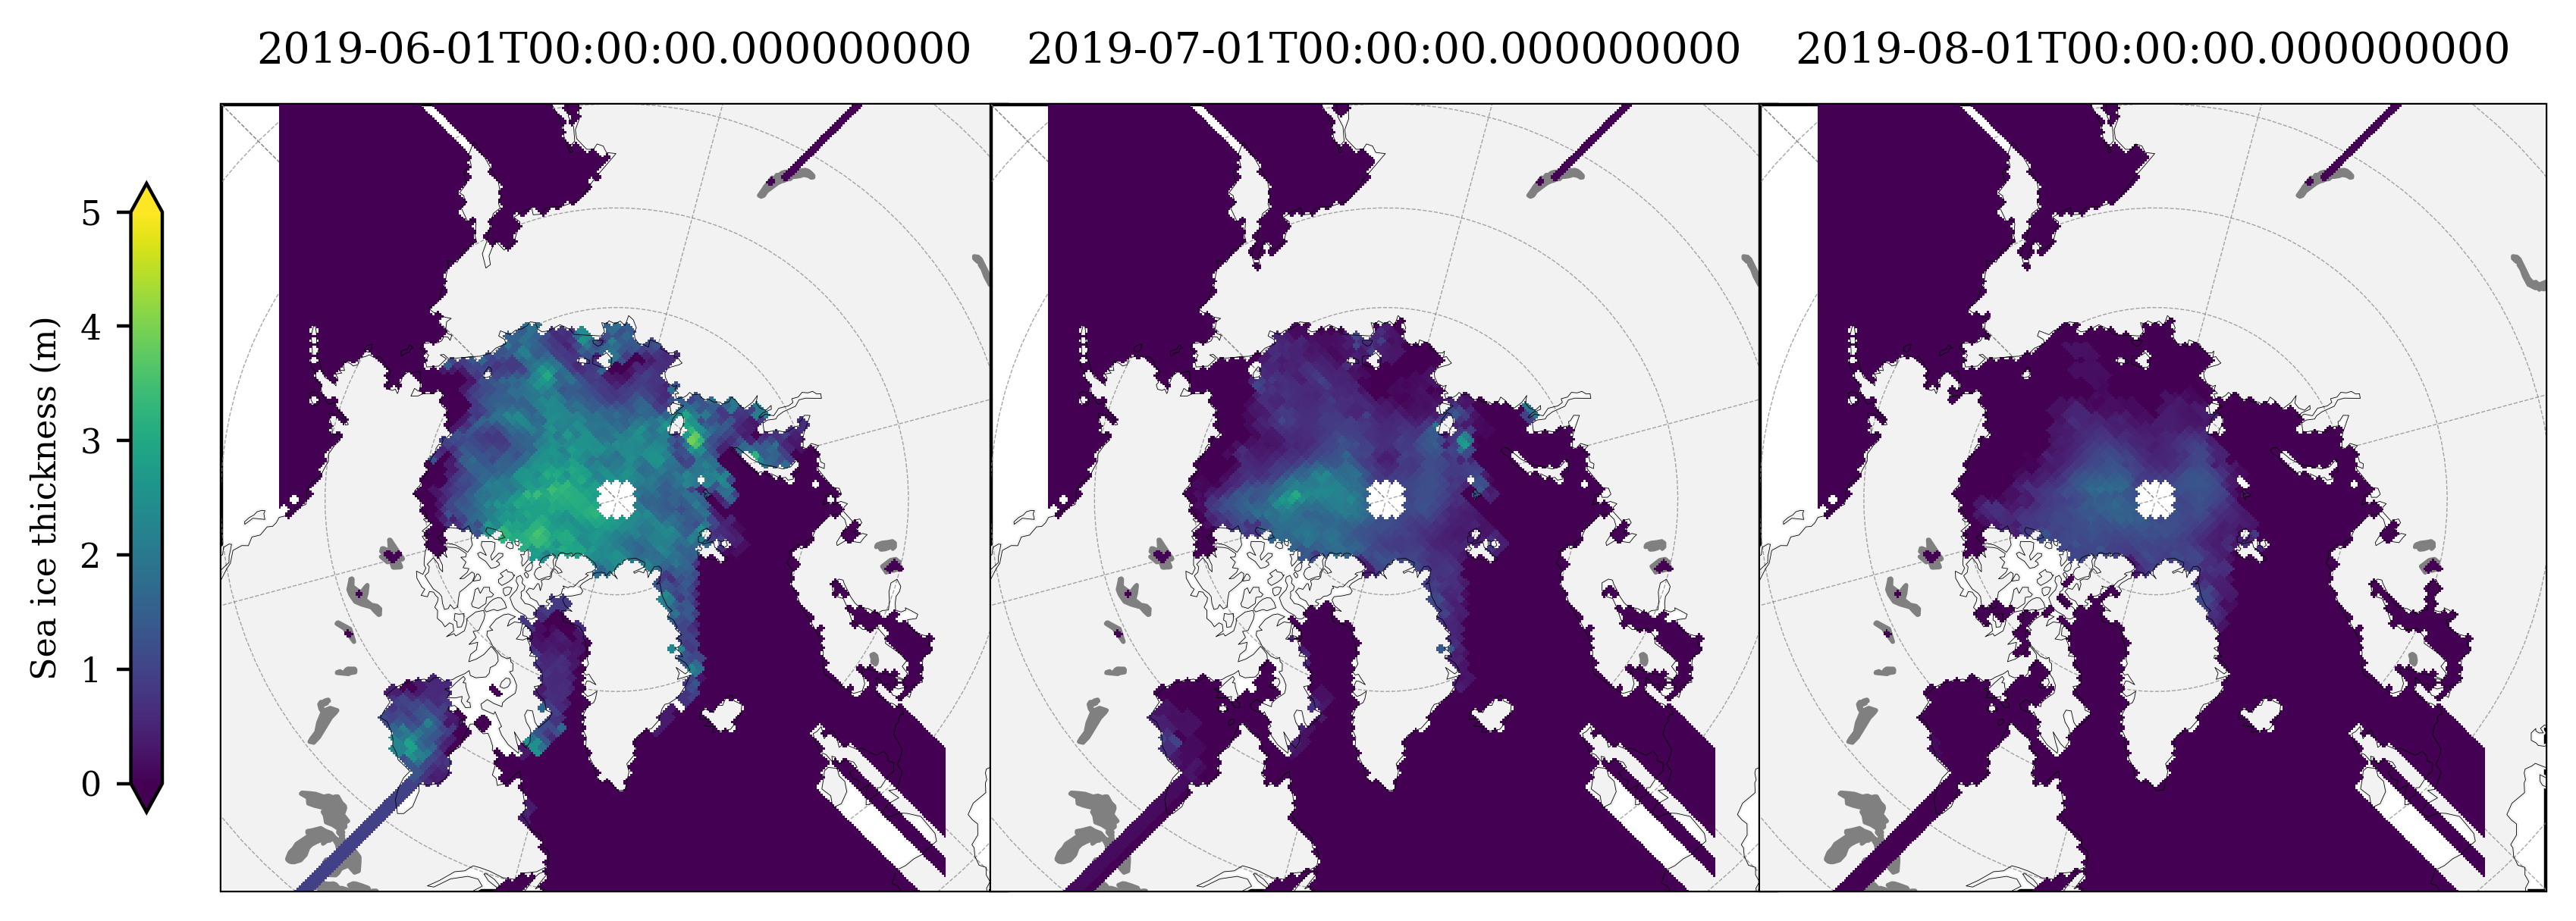

In [21]:
from utils.plotting_utils import static_winter_comparison_lineplot, staticArcticMaps
plot = IS2SITMOGR4_v3['cs2_sea_ice_thickness_UBRIS'].sel(time=['2019-06', '2019-07', '2019-08'])
staticArcticMaps(plot, dates=plot.time.values,title="", set_cbarlabel = "Sea ice thickness (m)", col_wrap=3, cmap="viridis", vmin=0, vmax=5, out_str='thickness_summer_2019_2021')


In [24]:
IS2SITMOGR4_v3.time

<xarray.DataArray 'time' (time: 57)>
array(['2018-11-01T00:00:00.000000000', '2018-12-01T00:00:00.000000000',
       '2019-01-01T00:00:00.000000000', '2019-02-01T00:00:00.000000000',
       '2019-03-01T00:00:00.000000000', '2019-04-01T00:00:00.000000000',
       '2019-05-01T00:00:00.000000000', '2019-06-01T00:00:00.000000000',
       '2019-07-01T00:00:00.000000000', '2019-08-01T00:00:00.000000000',
       '2019-09-01T00:00:00.000000000', '2019-10-01T00:00:00.000000000',
       '2019-11-01T00:00:00.000000000', '2019-12-01T00:00:00.000000000',
       '2020-01-01T00:00:00.000000000', '2020-02-01T00:00:00.000000000',
       '2020-03-01T00:00:00.000000000', '2020-04-01T00:00:00.000000000',
       '2020-05-01T00:00:00.000000000', '2020-06-01T00:00:00.000000000',
       '2020-07-01T00:00:00.000000000', '2020-08-01T00:00:00.000000000',
       '2020-09-01T00:00:00.000000000', '2020-10-01T00:00:00.000000000',
       '2020-11-01T00:00:00.000000000', '2020-12-01T00:00:00.000000000',
       '2021-01-01T00:00:00.000000000', '2021-02-01T00:00:00.000000000',
       '2021-03-01T00:00:00.000000000', '2021-04-01T00:00:00.000000000',
       '2021-05-01T00:00:00.000000000', '2021-06-01T00:00:00.000000000',
       '2021-07-01T00:00:00.000000000', '2021-09-01T00:00:00.000000000',
       '2021-10-01T00:00:00.000000000', '2021-11-01T00:00:00.000000000',
       '2021-12-01T00:00:00.000000000', '2022-01-01T00:00:00.000000000',
       '2022-02-01T00:00:00.000000000', '2022-03-01T00:00:00.000000000',
       '2022-04-01T00:00:00.000000000', '2022-09-01T00:00:00.000000000',
       '2022-10-01T00:00:00.000000000', '2022-11-01T00:00:00.000000000',
       '2022-12-01T00:00:00.000000000', '2023-01-01T00:00:00.000000000',
       '2023-02-01T00:00:00.000000000', '2023-03-01T00:00:00.000000000',
       '2023-04-01T00:00:00.000000000', '2023-09-01T00:00:00.000000000',
       '2023-10-01T00:00:00.000000000', '2023-11-01T00:00:00.000000000',
       '2023-12-01T00:00:00.000000000', '2024-01-01T00:00:00.000000000',
       '2024-02-01T00:00:00.000000000', '2024-03-01T00:00:00.000000000',
       '2024-04-01T00:00:00.000000000'], dtype='datetime64[ns]')
Coordinates:
  * time     (time) datetime64[ns] 2018-11-01 2018-12-01 ... 2024-04-01

In [26]:
def grid_IS2_nearby(date, option, uls_x, uls_y, res=50000):
    print(date)
    IS2 = IS2SITMOGR4_v3['ice_draft_'+option].sel(time=date)
    #xptsIS2g, yptsIS2g = mapProj(IS2.longitude.values, IS2.latitude.values)
    
    dist = np.sqrt( (xptsIS2 - uls_x)**2 + (yptsIS2 - uls_y)**2 )
    
    IS2_uls = IS2.where(dist<res).mean(skipna=True).values
    
    #print('Number of valid IS-2 grid cells in month '+str(date)[0:7]+':', np.count_nonzero(~np.isnan(IS2.where(dist<res))))
    
    #Another option I first explored, coarsen the data then do nearest neighbor...provided similar results but above is more flexible.
    #if coarse_res>1:
    #Coarsen array by coarse_res in x/y directions (note that each grid-cell represents 25 km so 4 = 100 km)
    #    IS2 = IS2.coarsen(x=res, y=res, boundary='pad').mean()
    #IS2_uls = scipy.interpolate.griddata((xptsIS2.flatten(), yptsIS2.flatten()), IS2.values.flatten(), (uls_x, uls_y), method = 'nearest')
    print(date, option, IS2_uls)
    return IS2_uls


# Compute monthly ULS values for each option
monthly_IS2_at_ULS_a_options = {}
monthly_IS2_at_ULS_b_options = {}
monthly_IS2_at_ULS_d_options = {}
monthly_IS2_at_ULS_all_options = {}

for option in options.keys():
    monthly_IS2_at_ULS_a_options[option] = [
        grid_IS2_nearby(date, option, uls_x_a, uls_y_a, res=comp_res) for date in IS2_date_range
    ]
    monthly_IS2_at_ULS_b_options[option] = [
        grid_IS2_nearby(date, option,uls_x_b, uls_y_b, res=comp_res) for date in IS2_date_range
    ]
    monthly_IS2_at_ULS_d_options[option] = [
        grid_IS2_nearby(date, option,uls_x_d, uls_y_d, res=comp_res) for date in IS2_date_range
    ]
    # Combine all ULS values for the current option
    monthly_IS2_at_ULS_all_options[option] = (
        monthly_IS2_at_ULS_a_options[option] +
        monthly_IS2_at_ULS_b_options[option] +
        monthly_IS2_at_ULS_d_options[option]
    )


2019-05-15 00:00:00
2019-05-15 00:00:00 IS-2/SM 2.2683637
2019-06-15 00:00:00
2019-06-15 00:00:00 IS-2/SM 1.9358462
2019-07-15 00:00:00
2019-07-15 00:00:00 IS-2/SM nan
2019-08-15 00:00:00
2019-08-15 00:00:00 IS-2/SM nan
2020-05-15 00:00:00
2020-05-15 00:00:00 IS-2/SM 1.7251667
2020-06-15 00:00:00
2020-06-15 00:00:00 IS-2/SM 1.8589231
2020-07-15 00:00:00
2020-07-15 00:00:00 IS-2/SM 0.7273846
2020-08-15 00:00:00
2020-08-15 00:00:00 IS-2/SM 0.5566667
2021-05-15 00:00:00
2021-05-15 00:00:00 IS-2/SM 2.1494286
2021-06-15 00:00:00
2021-06-15 00:00:00 IS-2/SM 1.593
2021-07-15 00:00:00
2021-07-15 00:00:00 IS-2/SM 0.74
2019-05-15 00:00:00
2019-05-15 00:00:00 IS-2/SM 2.142857
2019-06-15 00:00:00
2019-06-15 00:00:00 IS-2/SM 2.2921429
2019-07-15 00:00:00
2019-07-15 00:00:00 IS-2/SM 0.9342
2019-08-15 00:00:00
2019-08-15 00:00:00 IS-2/SM 0.8097
2020-05-15 00:00:00
2020-05-15 00:00:00 IS-2/SM 1.5952145
2020-06-15 00:00:00
2020-06-15 00:00:00 IS-2/SM 1.6615715
2020-07-15 00:00:00
2020-07-15 00:00:00 IS

In [27]:
uls_dates=uls_mean_monthly_draft_a.index.astype(str)
uls_mean_monthly_draft_a_IS2_period  = [get_ULS_dates(uls_mean_monthly_draft_a, uls_dates, date) for date in IS2_date_range_strs]

uls_dates=uls_mean_monthly_draft_b.index.astype(str)
uls_mean_monthly_draft_b_IS2_period  = [get_ULS_dates(uls_mean_monthly_draft_b, uls_dates, date) for date in IS2_date_range_strs]

uls_dates=uls_mean_monthly_draft_d.index.astype(str)
uls_mean_monthly_draft_d_IS2_period  = [get_ULS_dates(uls_mean_monthly_draft_d, uls_dates, date) for date in IS2_date_range_strs]
                                        
uls_mean_monthly_draft_IS2_period = uls_mean_monthly_draft_a_IS2_period+uls_mean_monthly_draft_b_IS2_period+uls_mean_monthly_draft_d_IS2_period


In [28]:
# Validation analysis for each option
validation_results = {}

for option in options.keys():
    print(option)
    # ULS A
    mask_a = ~np.isnan(monthly_IS2_at_ULS_a_options[option])& ~np.isnan(uls_mean_monthly_draft_a_IS2_period)
    res_a = stats.linregress(
        np.array(monthly_IS2_at_ULS_a_options[option])[mask_a],
        np.array(uls_mean_monthly_draft_a_IS2_period)[mask_a]
    )
    r_str_a = '%.02f' % (res_a[2]**2)
    mb_str_a = '%.02f' % (np.nanmean(np.array(monthly_IS2_at_ULS_a_options[option]) - np.array(uls_mean_monthly_draft_a_IS2_period)))
    sd_str_a = '%.02f' % (np.nanstd(np.array(monthly_IS2_at_ULS_a_options[option]) - np.array(uls_mean_monthly_draft_a_IS2_period)))

    # ULS B
    mask_b = ~np.isnan(monthly_IS2_at_ULS_b_options[option])& ~np.isnan(uls_mean_monthly_draft_b_IS2_period)
    res_b = stats.linregress(
        np.array(monthly_IS2_at_ULS_b_options[option])[mask_b],
        np.array(uls_mean_monthly_draft_b_IS2_period)[mask_b]
    )
    r_str_b = '%.02f' % (res_b[2]**2)
    mb_str_b = '%.02f' % (np.nanmean(np.array(monthly_IS2_at_ULS_b_options[option]) - np.array(uls_mean_monthly_draft_b_IS2_period)))
    sd_str_b = '%.02f' % (np.nanstd(np.array(monthly_IS2_at_ULS_b_options[option]) - np.array(uls_mean_monthly_draft_b_IS2_period)))

    # ULS D
    mask_d = ~np.isnan(monthly_IS2_at_ULS_d_options[option])& ~np.isnan(uls_mean_monthly_draft_b_IS2_period)
    res_d = stats.linregress(
        np.array(monthly_IS2_at_ULS_d_options[option])[mask_d],
        np.array(uls_mean_monthly_draft_d_IS2_period)[mask_d]
    )
    r_str_d = '%.02f' % (res_d[2]**2)
    mb_str_d = '%.02f' % (np.nanmean(np.array(monthly_IS2_at_ULS_d_options[option]) - np.array(uls_mean_monthly_draft_d_IS2_period)))
    sd_str_d = '%.02f' % (np.nanstd(np.array(monthly_IS2_at_ULS_d_options[option]) - np.array(uls_mean_monthly_draft_d_IS2_period)))

    # ULS ALL
    mask_all = ~np.isnan(monthly_IS2_at_ULS_all_options[option])& ~np.isnan(uls_mean_monthly_draft_IS2_period)
    res_all = stats.linregress(
        np.array(monthly_IS2_at_ULS_all_options[option])[mask_all],
        np.array(uls_mean_monthly_draft_IS2_period)[mask_all]
    )
    r_str_all = '%.02f' % (res_all[2]**2)
    mb_str_all = '%.02f' % (np.nanmean(np.array(monthly_IS2_at_ULS_all_options[option]) - np.array(uls_mean_monthly_draft_IS2_period)))
    sd_str_all = '%.02f' % (np.nanstd(np.array(monthly_IS2_at_ULS_all_options[option]) - np.array(uls_mean_monthly_draft_IS2_period)))

    # Store results
    validation_results[option] = {
        'r_str_a': r_str_a, 'mb_str_a': mb_str_a, 'sd_str_a': sd_str_a,
        'r_str_b': r_str_b, 'mb_str_b': mb_str_b, 'sd_str_b': sd_str_b,
        'r_str_d': r_str_d, 'mb_str_d': mb_str_d, 'sd_str_d': sd_str_d,
        'r_str_all': r_str_all, 'mb_str_all': mb_str_all, 'sd_str_all': sd_str_all
    }

validation_results

IS-2/SM
CS-2/SM


{'IS-2/SM': {'r_str_a': '0.64',
  'mb_str_a': '0.11',
  'sd_str_a': '0.38',
  'r_str_b': '0.67',
  'mb_str_b': '0.18',
  'sd_str_b': '0.37',
  'r_str_d': '0.77',
  'mb_str_d': '-0.06',
  'sd_str_d': '0.37',
  'r_str_all': '0.65',
  'mb_str_all': '0.07',
  'sd_str_all': '0.39'},
 'CS-2/SM': {'r_str_a': '0.60',
  'mb_str_a': '-0.28',
  'sd_str_a': '0.34',
  'r_str_b': '0.89',
  'mb_str_b': '0.26',
  'sd_str_b': '0.33',
  'r_str_d': '0.50',
  'mb_str_d': '-0.46',
  'sd_str_d': '0.40',
  'r_str_all': '0.47',
  'mb_str_all': '-0.17',
  'sd_str_all': '0.47'}}

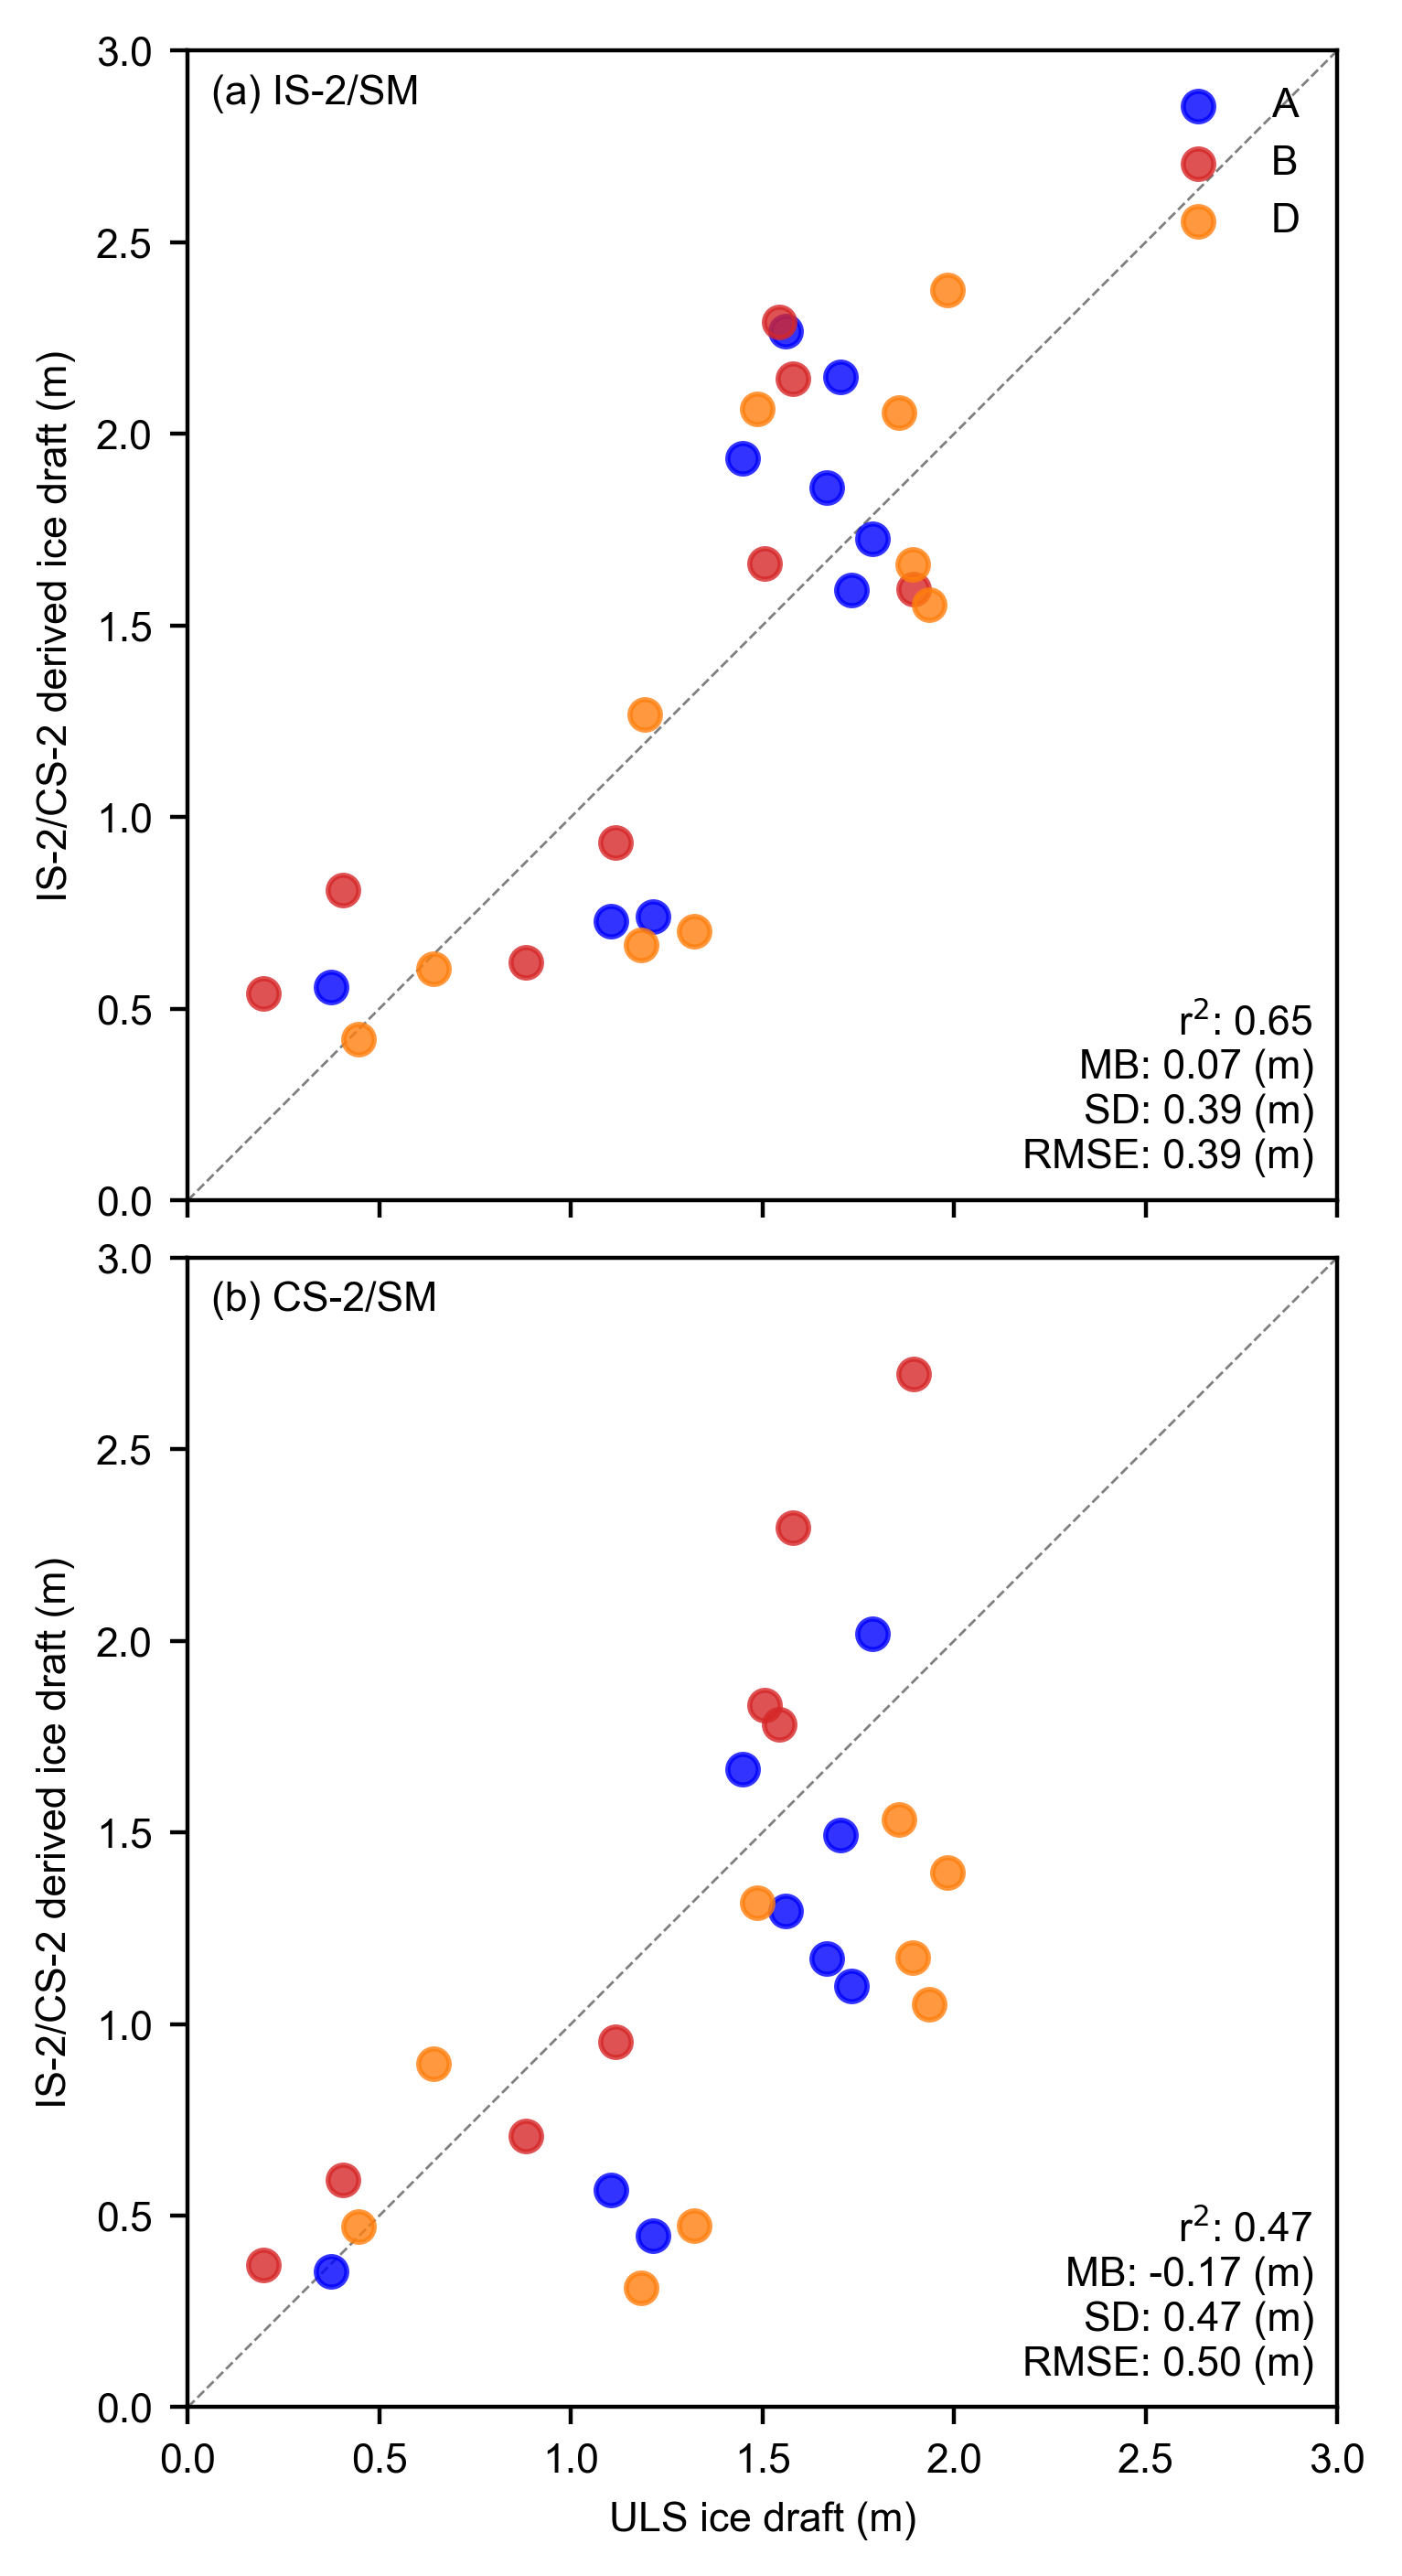

In [31]:
import matplotlib as mpl

mpl.rcParams.update({
    "text.usetex": False,  # Use LaTeX for rendering
    "font.family": "serif",
    "font.size": 8,  # Match typical LaTeX 10pt font
    "axes.labelsize": 8,
    "xtick.labelsize": 8,
    "ytick.labelsize": 8,
    "legend.fontsize": 8
})

# Validation plot with subplots for each option
plt.rc('font', **{'family': 'sans-serif', 'sans-serif': ['Arial']})

# Create a single column with two rows for the two options
fig, axes = plt.subplots(2, 1, figsize=(3.9, 7), gridspec_kw={'hspace': 0.05})  # Adjust hspace for less whitespace
axes = axes.flatten()  # Flatten the 2D array of axes for easy iteration
panel_labels = ['(a)', '(b)']  # Panel labels

# Iterate over the first two options
for i, option in enumerate(list(options.keys())[:2]):
    ax = axes[i]
    ax.scatter(uls_mean_monthly_draft_a_IS2_period, monthly_IS2_at_ULS_a_options[option], color='b', alpha=0.8, label='A')
    ax.scatter(uls_mean_monthly_draft_b_IS2_period, monthly_IS2_at_ULS_b_options[option], color='tab:red', alpha=0.8, label='B')
    ax.scatter(uls_mean_monthly_draft_d_IS2_period, monthly_IS2_at_ULS_d_options[option], color='tab:orange', alpha=0.8, label='D')

    # Retrieve validation results for the current option
    r_str_all = validation_results[option]['r_str_all']
    mb_str_all = validation_results[option]['mb_str_all']
    sd_str_all = validation_results[option]['sd_str_all']
    rmse_all = np.sqrt(np.nanmean((np.array(monthly_IS2_at_ULS_all_options[option]) - np.array(uls_mean_monthly_draft_IS2_period))**2))

    # Annotate the plot with RMSE, mean bias, and standard deviation
    ax.annotate(f"r$^2$: {r_str_all} \nMB: {mb_str_all} (m)\nSD: {sd_str_all} (m)\nRMSE: {rmse_all:.02f} (m)", color='k', xy=(0.98, 0.02), xycoords='axes fraction', horizontalalignment='right', verticalalignment='bottom')

    # Combine panel label with option label
    ax.annotate(f"{panel_labels[i]} "+option, xy=(0.02, 0.98), xycoords='axes fraction', horizontalalignment='left', verticalalignment='top')

    # Set x and y labels only for the leftmost and bottom plots
    if i == 0:
        ax.legend(frameon=False, loc="upper right")
        ax.set_xticklabels('')
        ax.set_xlabel('')
    else:
        ax.set_xlabel('ULS ice draft (m)')
    ax.set_ylabel('IS-2/CS-2 derived ice draft (m)')
    

    ax.set_xlim([0, 3])
    ax.set_ylim([0, 3])
    lims = [
        np.min([ax.get_xlim(), ax.get_ylim()]),  # min of both axes
        np.max([ax.get_xlim(), ax.get_ylim()]),  # max of both axes
    ]
    ax.plot(lims, lims, 'k--', linewidth=0.5, alpha=0.5, zorder=0)
    ax.set_aspect('equal')
    ax.set_xlim(lims)
    ax.set_ylim(lims)

plt.subplots_adjust(left=0.065, right=0.98, top=0.98, bottom=0.06)  # Adjust these values to reduce whitespace

plt.savefig('./figs/BGEP_summer_scatter_res'+str(comp_res)+'_nn_'+start_date+end_date+'_inccs2.pdf', dpi=300)
plt.show()